## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 3 - Notebook 3 - Perceptron Learning Algorithm
---

## Importing the Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets, preprocessing

In [2]:
def plot_decision_boundary(X, y, w1, w2, b, str_title):
    """
    Plots the Perceptron decision boundary.
    """

    # Defines the extreme points of the decision boundary.
    x1_min = X[:, 0].min() - 1.
    x1_max = X[:, 0].max() + 1.

    colors = ['r', 'g', 'b', 'y', 'c', 'm']

    plt.figure()

    # Plots the training set.
    for y_ in np.unique(y):
        plt.scatter(
            X[y == y_, 0],
            X[y == y_, 1],
            color=colors[y_],
            label=str(y_)
        )

    # Plots the decision boundary:
    # w1*x1 + w2*x2 + b = 0
    if w2 != 0:
        x1 = np.array([x1_min, x1_max])
        x2 = -(w1 / w2) * x1 - (b / w2)

        plt.plot(x1, x2, color='k')

    elif w1 != 0:
        # Vertical decision boundary:
        # w1*x1 + b = 0
        x1 = -b / w1
        plt.axvline(x=x1, color='k')

    # Labels, legend and title.
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.title(str_title)

    # Set visualization limits.
    plt.xlim(X[:, 0].min() - .5, X[:, 0].max() + .5)
    plt.ylim(X[:, 1].min() - .5, X[:, 1].max() + .5)

    # Coordinate axes.
    plt.axhline(y=0, color='gray', linewidth=1)
    plt.axvline(x=0, color='gray', linewidth=1)

    # Grid.
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.gca().set_axisbelow(True)

    plt.show()

## Perceptron Learning Algorithm

For each training sample, the Perceptron computes

$
v = \mathbf{w}^T\mathbf{x}+b
$

and applies the step activation function

$
\hat{y} =
\begin{cases}
1, & v \geq 0 \\
0, & v < 0.
\end{cases}
$

The prediction error is

$
e = y-\hat{y}.
$

The parameters are then updated as

$
\mathbf{w} \leftarrow \mathbf{w}+\eta e\mathbf{x}
$

$
b \leftarrow b+\eta e,
$

where $\eta$ is the learning rate.

The process is repeated over the training set until all samples are correctly classified or the maximum number of epochs is reached.

In [3]:
def fit(X, y, max_iter, learning_rate, plot=True, verbose=True):
    """
    Trains the Perceptron.
    """

    print('Initialization')
    print('====================')

    # Weights (w) initialization.
    w = np.random.rand(X.shape[1])
    print(f'\nWeights: {np.round(w, 4)}')

    # Bias (b) initialization.
    b = np.random.rand()
    print(f'Bias: {b:.4f}')

    # List of epoch errors.
    epoch_errors = []

    # Plot the initial decision boundary.
    if plot:
        plot_decision_boundary(
            X, y, w[0], w[1], b,
            'Initialization'
        )

    # Iterate over the training epochs.
    for i in range(max_iter):

        print(f'\nEpoch {i + 1}')
        print('====================')

        # Epoch error.
        epoch_error = 0

        # Iterate over the training samples.
        for j in range(X.shape[0]):

            if verbose:
                print(f'\nIteration {j + 1}')
                print('--------------------')
                print(f'x: {X[j, :]}, y: {y[j]}')

            # Weighted sum.
            v = np.dot(X[j, :], w) + b
            if verbose:
                print(f'v: {v:.4f}')

            # Step activation function.
            y_out = 1 if v >= 0 else 0
            if verbose:
                print(f'y_out: {y_out}')

            # Error.
            error = y[j] - y_out
            if verbose:
                print(f'Error: {error}')

            # Update the epoch error.
            epoch_error = epoch_error + error**2

            # Update the weights.
            w = w + learning_rate * error * X[j, :]
            if verbose:
                print(f'Weights: {np.round(w, 4)}')

            # Update the bias.
            b = b + learning_rate * error
            if verbose:
                print(f'Bias: {b:.4f}')

        print('--------------------')
        print(f'\nEpoch error: {epoch_error}')

        # Store the epoch error.
        epoch_errors.append(epoch_error)

        # Plot the decision boundary.
        if plot:
            plot_decision_boundary(
                X, y, w[0], w[1], b,
                f'Epoch {i + 1}'
            )

        # Stop if all samples are correctly classified.
        if epoch_error == 0:
            break

    return w, b, epoch_errors

## Defining Datasets: Binary Logic Functions

We first train the Perceptron using simple binary logic functions.

The four possible combinations of two binary inputs are

$
(x_1,x_2) \in \{(0,0),(0,1),(1,0),(1,1)\}.
$

The corresponding labels are defined for the AND, OR, and XOR functions.

In [4]:
# Binary input data
X_bin = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Binary logic functions
# ======================

# AND
y_and = np.array([0, 0, 0, 1])

# OR
y_or = np.array([0, 1, 1, 1])

# XOR
y_xor = np.array([0, 1, 1, 0])

### Select a Logic Function

In [5]:
X = X_bin
y = y_and
title = 'AND'

print(f'Logic function: {title}')

Logic function: AND


## Training the model with binary functions

The decision boundary is displayed after initialization and after each training epoch.

Initialization

Weights: [0.3745 0.9507]
Bias: 0.7320


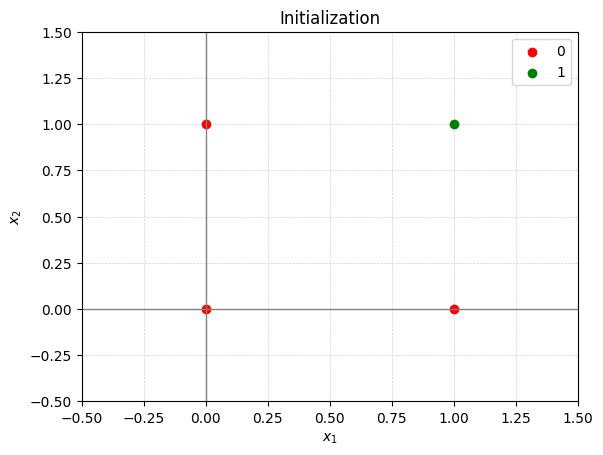


Epoch 1

Iteration 1
--------------------
x: [0 0], y: 0
v: 0.7320
y_out: 1
Error: -1
Weights: [0.3745 0.9507]
Bias: 0.6320

Iteration 2
--------------------
x: [0 1], y: 0
v: 1.5827
y_out: 1
Error: -1
Weights: [0.3745 0.8507]
Bias: 0.5320

Iteration 3
--------------------
x: [1 0], y: 0
v: 0.9065
y_out: 1
Error: -1
Weights: [0.2745 0.8507]
Bias: 0.4320

Iteration 4
--------------------
x: [1 1], y: 1
v: 1.5572
y_out: 1
Error: 0
Weights: [0.2745 0.8507]
Bias: 0.4320
--------------------

Epoch error: 3


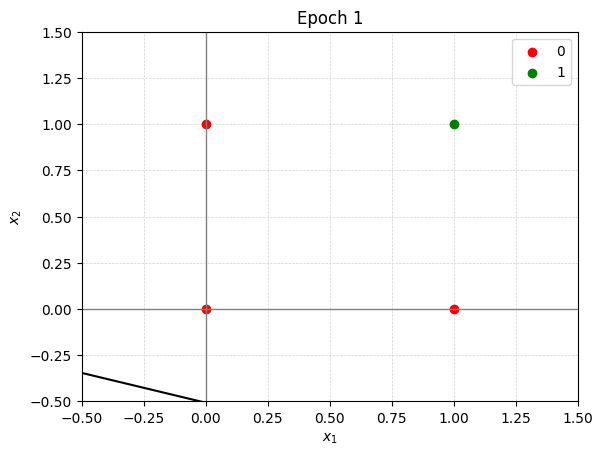


Epoch 2

Iteration 1
--------------------
x: [0 0], y: 0
v: 0.4320
y_out: 1
Error: -1
Weights: [0.2745 0.8507]
Bias: 0.3320

Iteration 2
--------------------
x: [0 1], y: 0
v: 1.1827
y_out: 1
Error: -1
Weights: [0.2745 0.7507]
Bias: 0.2320

Iteration 3
--------------------
x: [1 0], y: 0
v: 0.5065
y_out: 1
Error: -1
Weights: [0.1745 0.7507]
Bias: 0.1320

Iteration 4
--------------------
x: [1 1], y: 1
v: 1.0572
y_out: 1
Error: 0
Weights: [0.1745 0.7507]
Bias: 0.1320
--------------------

Epoch error: 3


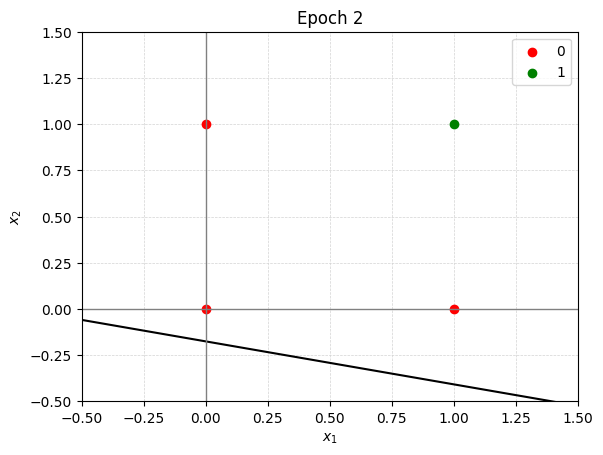


Epoch 3

Iteration 1
--------------------
x: [0 0], y: 0
v: 0.1320
y_out: 1
Error: -1
Weights: [0.1745 0.7507]
Bias: 0.0320

Iteration 2
--------------------
x: [0 1], y: 0
v: 0.7827
y_out: 1
Error: -1
Weights: [0.1745 0.6507]
Bias: -0.0680

Iteration 3
--------------------
x: [1 0], y: 0
v: 0.1065
y_out: 1
Error: -1
Weights: [0.0745 0.6507]
Bias: -0.1680

Iteration 4
--------------------
x: [1 1], y: 1
v: 0.5572
y_out: 1
Error: 0
Weights: [0.0745 0.6507]
Bias: -0.1680
--------------------

Epoch error: 3


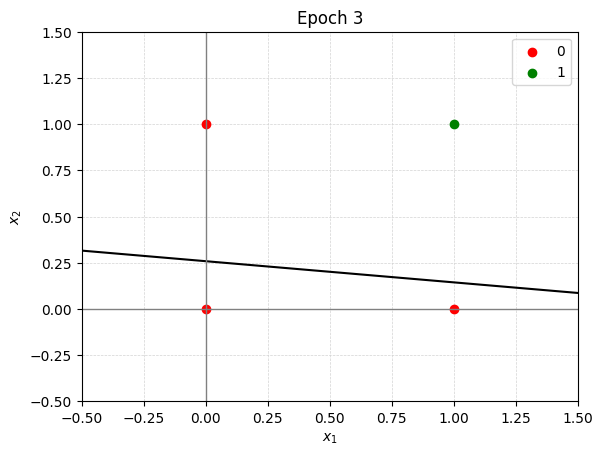


Epoch 4

Iteration 1
--------------------
x: [0 0], y: 0
v: -0.1680
y_out: 0
Error: 0
Weights: [0.0745 0.6507]
Bias: -0.1680

Iteration 2
--------------------
x: [0 1], y: 0
v: 0.4827
y_out: 1
Error: -1
Weights: [0.0745 0.5507]
Bias: -0.2680

Iteration 3
--------------------
x: [1 0], y: 0
v: -0.1935
y_out: 0
Error: 0
Weights: [0.0745 0.5507]
Bias: -0.2680

Iteration 4
--------------------
x: [1 1], y: 1
v: 0.3572
y_out: 1
Error: 0
Weights: [0.0745 0.5507]
Bias: -0.2680
--------------------

Epoch error: 1


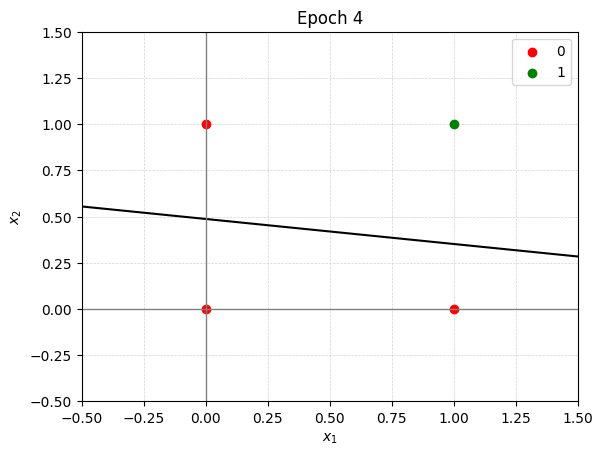


Epoch 5

Iteration 1
--------------------
x: [0 0], y: 0
v: -0.2680
y_out: 0
Error: 0
Weights: [0.0745 0.5507]
Bias: -0.2680

Iteration 2
--------------------
x: [0 1], y: 0
v: 0.2827
y_out: 1
Error: -1
Weights: [0.0745 0.4507]
Bias: -0.3680

Iteration 3
--------------------
x: [1 0], y: 0
v: -0.2935
y_out: 0
Error: 0
Weights: [0.0745 0.4507]
Bias: -0.3680

Iteration 4
--------------------
x: [1 1], y: 1
v: 0.1572
y_out: 1
Error: 0
Weights: [0.0745 0.4507]
Bias: -0.3680
--------------------

Epoch error: 1


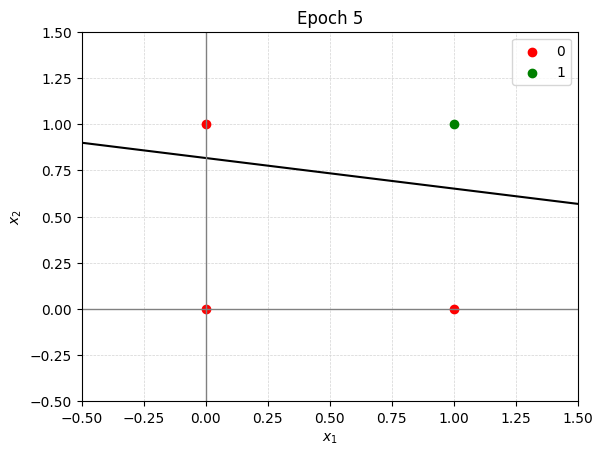


Epoch 6

Iteration 1
--------------------
x: [0 0], y: 0
v: -0.3680
y_out: 0
Error: 0
Weights: [0.0745 0.4507]
Bias: -0.3680

Iteration 2
--------------------
x: [0 1], y: 0
v: 0.0827
y_out: 1
Error: -1
Weights: [0.0745 0.3507]
Bias: -0.4680

Iteration 3
--------------------
x: [1 0], y: 0
v: -0.3935
y_out: 0
Error: 0
Weights: [0.0745 0.3507]
Bias: -0.4680

Iteration 4
--------------------
x: [1 1], y: 1
v: -0.0428
y_out: 0
Error: 1
Weights: [0.1745 0.4507]
Bias: -0.3680
--------------------

Epoch error: 2


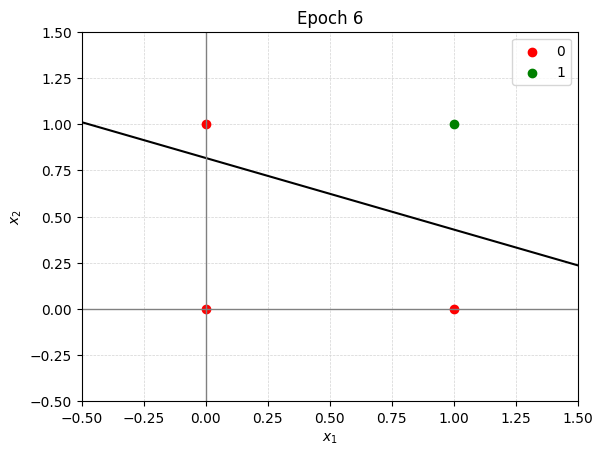


Epoch 7

Iteration 1
--------------------
x: [0 0], y: 0
v: -0.3680
y_out: 0
Error: 0
Weights: [0.1745 0.4507]
Bias: -0.3680

Iteration 2
--------------------
x: [0 1], y: 0
v: 0.0827
y_out: 1
Error: -1
Weights: [0.1745 0.3507]
Bias: -0.4680

Iteration 3
--------------------
x: [1 0], y: 0
v: -0.2935
y_out: 0
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680

Iteration 4
--------------------
x: [1 1], y: 1
v: 0.0572
y_out: 1
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680
--------------------

Epoch error: 1


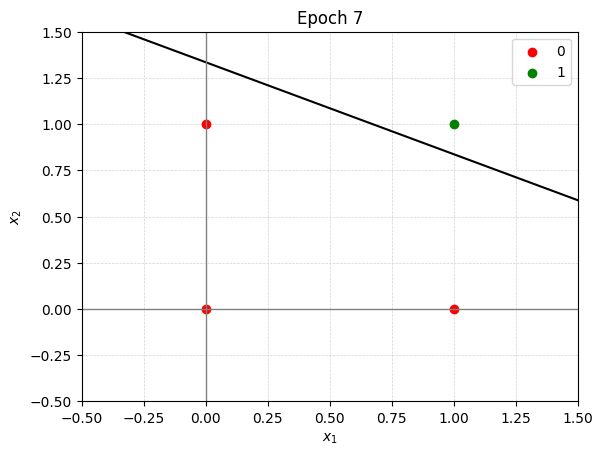


Epoch 8

Iteration 1
--------------------
x: [0 0], y: 0
v: -0.4680
y_out: 0
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680

Iteration 2
--------------------
x: [0 1], y: 0
v: -0.1173
y_out: 0
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680

Iteration 3
--------------------
x: [1 0], y: 0
v: -0.2935
y_out: 0
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680

Iteration 4
--------------------
x: [1 1], y: 1
v: 0.0572
y_out: 1
Error: 0
Weights: [0.1745 0.3507]
Bias: -0.4680
--------------------

Epoch error: 0


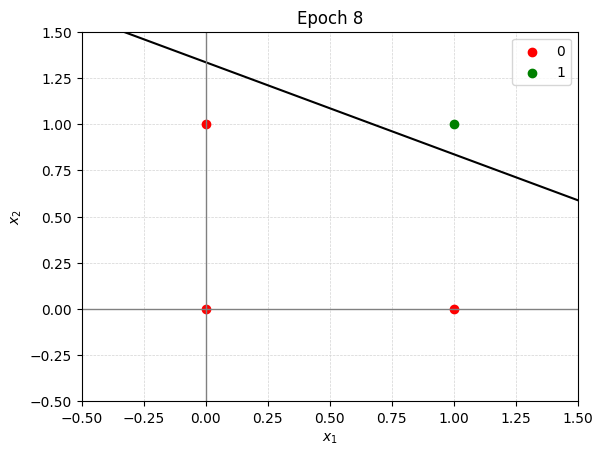

In [6]:
# Maximum number of epochs.
max_iter = 10

# Learning rate.
learning_rate = 0.1

# Set the random number generator seed.
np.random.seed(42)

# Train the model.
w, b, epoch_errors = fit(
    X, y,
    max_iter,
    learning_rate
)

## Training the model with the Iris dataset

We now apply the same learning algorithm to two classes and two attributes from the Iris dataset.

We use:

- Classes: **Setosa (0)** and **Versicolor (1)**
- Attributes: **sepal length** and **sepal width**

The attributes are standardized before training.

In [7]:
# Load the Iris dataset.
iris = datasets.load_iris()

# Select only 2 classes: Setosa (0) and Versicolor (1).
# Select only 2 attributes: sepal length (0) and sepal width (1).
X = iris.data[iris.target < 2, :2]
y = iris.target[iris.target < 2]

# Data standardization.
X = preprocessing.scale(X)

print('Mean and standard deviation:')
print(X.mean(axis=0), X.std(axis=0))

Mean and standard deviation:
[-4.38538095e-15 -4.48530102e-16] [1. 1.]


Initialization

Weights: [0.3745 0.9507]
Bias: 0.7320


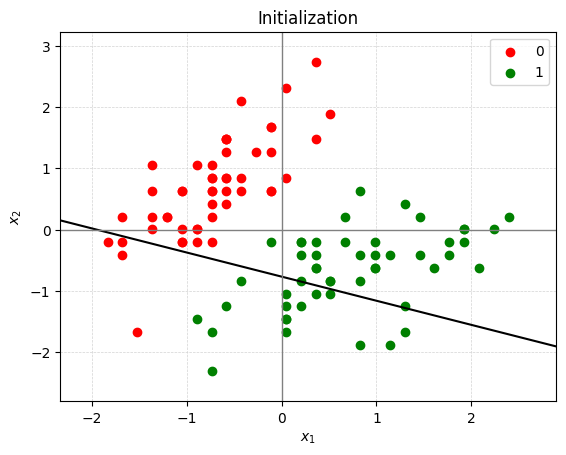


Epoch 1
--------------------

Epoch error: 51


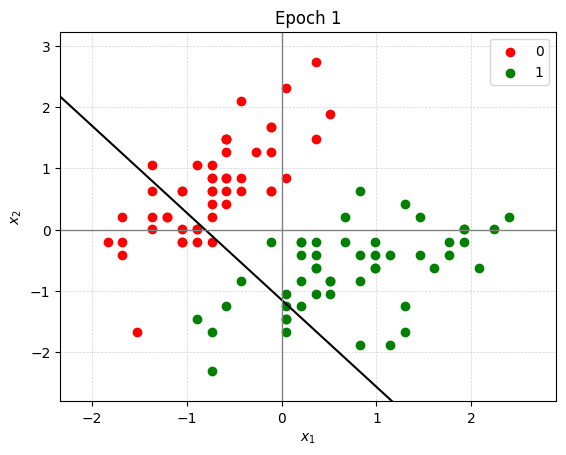


Epoch 2
--------------------

Epoch error: 29


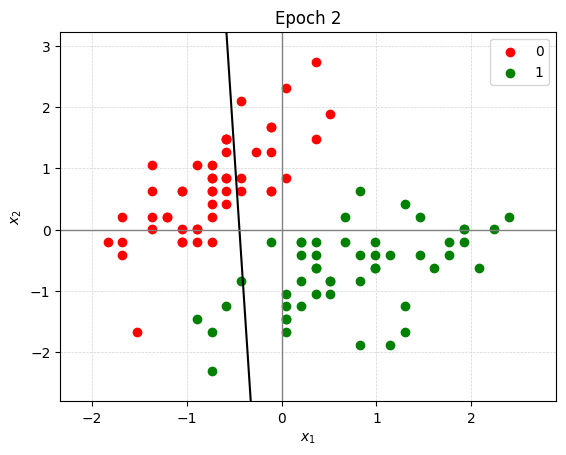


Epoch 3
--------------------

Epoch error: 12


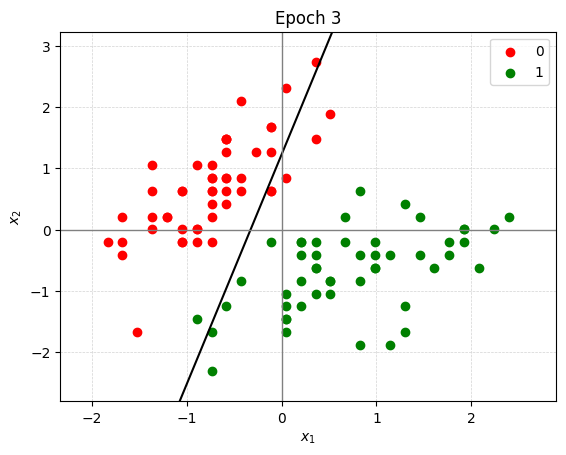


Epoch 4
--------------------

Epoch error: 4


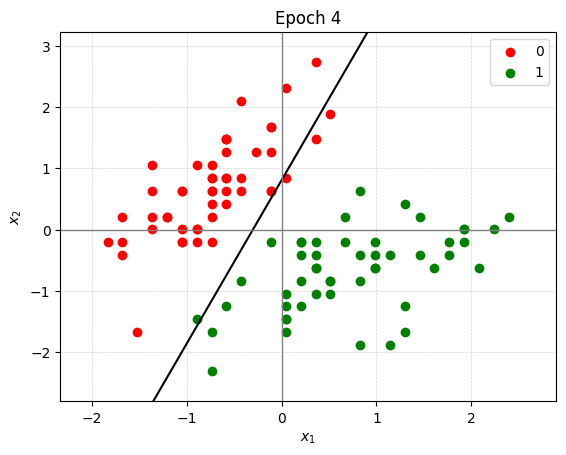


Epoch 5
--------------------

Epoch error: 2


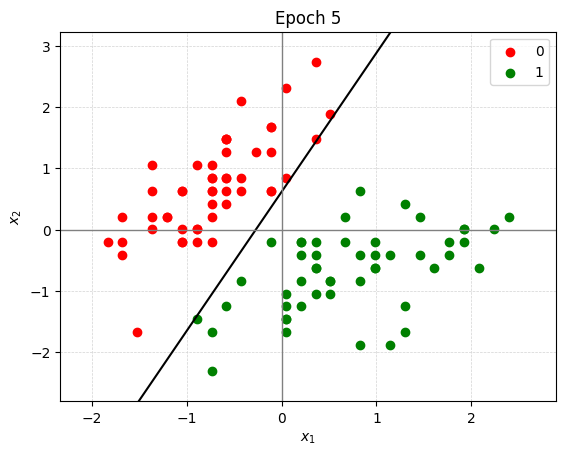


Epoch 6
--------------------

Epoch error: 0


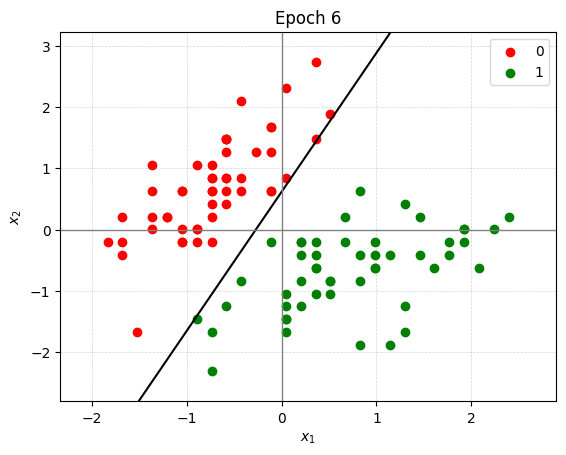

In [8]:
# Defines the hyperparameters and initial settings.
# -----------------------------------------------
# Maximum number of epochs.
max_iter = 40

# Learning rate.
learning_rate = 0.01

# Set the random number generator seed.
np.random.seed(42)

# Train the model.
w, b, epoch_errors = fit(
    X, y,
    max_iter,
    learning_rate,
    verbose=False
)

## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---

* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* ROSENBLATT, F. The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain. Psychological Review, 65(6), 386–408, 1958.
* scikit-learn - User Guide.
    * https://scikit-learn.org/stable/user_guide.html